# Emotion Classification 
- with RNNs, LSTMs and GRUs

### classifying text into 6 emotions (sadness ,joy love, anger, fear, surprise)

### Import Libraries


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#this library help to import dataset from  hugging face

from datasets import load_dataset



### 2 Load data set

In [6]:
emotion_dataset = load_dataset('dair-ai/emotion')

In [40]:
train_text=emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
test_text=emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [45]:
label_names = emotion_dataset['train'].features['label'].names


In [46]:
df_train = pd.DataFrame({
    'text': train_text,
    'label': [label_names[i] for i in train_label]
})

In [48]:
print(df_train.head())

                                                text    label
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


In [ ]:
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

# EDA (Exploratory Data Analysis)

<Axes: xlabel='label', ylabel='count'>

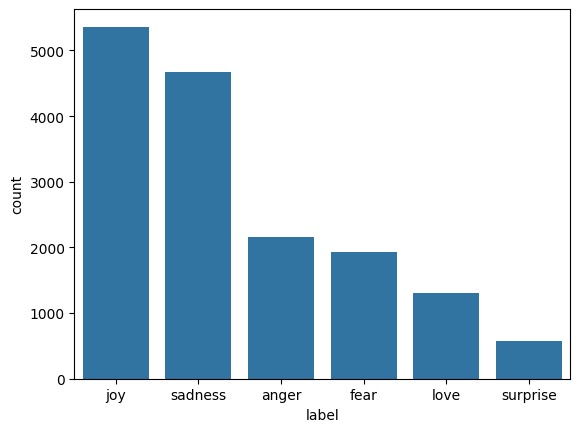

In [54]:
sns.countplot(x = 'label', data= df_train, order= df_train['label'].value_counts().index)

# Data Preprocessing - Using NLP
- tokenize text, pad sequences to max length 50, and convert labels into numpy array

In [60]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")